In [1]:
import numpy as np
from scipy.special import factorial
from scipy.stats import binned_statistic

In [2]:
import matplotlib.pyplot as plt

In [3]:
import scipy as sp

In [4]:
import sys
sys.path.append(r"C:/Users/xylin/Documents/Researches/multiphonon-direct-detection/StructureFactor1D.py")
from StructureFactor1D import StructureFactor1D

In [5]:
def get_q_lim(mass_DM, omega_threshold=10e-6):
    v_max = 0.00247 # in c
    q_min = mass_DM * v_max * (1 - np.sqrt(1-2*omega_threshold/(mass_DM * (v_max**2))))
    q_max = mass_DM * v_max * (1 + np.sqrt(1-2*omega_threshold/(mass_DM * (v_max**2))))
    return  q_min, q_max

def get_omega_lim(mass_DM, q,): 
    v_max = 0.00247 # in c
    return q * v_max - q**2 / (2 * mass_DM)


In [6]:
def get_impulse_approx(q, omega_list, omega_avg=40e-6, ):
    mass=26161e3 # sillicon, keV
    latticeConst= 2*np.pi/2.28 # si, keV^-3
    deltasq = q**2 * omega_avg/(2*mass)
    return 28**2 / ((latticeConst**3)/4) * np.sqrt(2*np.pi/deltasq) * np.exp(- (omega_list-(q**2/(2*mass)))**2 / (2*deltasq)) # uses averaged omega (not inverse of averaged inverse)


get s factor

In [7]:
np.sqrt(2*26161e3*13.13e-6)

26.210453258194523

In [8]:
max_omega = 1300*1e-6
omegalength = 4000
omegalist = np.linspace(0, max_omega,omegalength, ) 
qscale = np.sqrt(2*26161e3*13.13e-6) # uses averaged omega (not inverse of averaged inverse)
qlenth = 4000
qlist = np.linspace(0.01, 1e3, qlenth) # 2.5 sqrt(2m omega_bar)
2.5*qscale
q_list_nSite = qlist
omega_list_nSite = omegalist


In [9]:
omgplus = 20e-6 #keV
omgminus = 60e-6 #keV

dw = qlist**2/(8*26161e3)*(1/omgplus+1/omgminus)

In [10]:
# get n and j combo
nlist = np.arange(1,int(max_omega/omgplus)+1)
col1 = np.repeat(nlist, nlist+1) 
col2 = np.concatenate([np.arange(n + 1) for n in nlist])
pairs = np.column_stack((col1, col2))
mask = ( (pairs[:,0]-pairs[:,1])*omgminus + pairs[:,1]*omgplus ) < max_omega
pairs = pairs[mask]

In [11]:
omegalist_nobin = (pairs[:,0]-pairs[:,1])*omgminus + pairs[:,1]*omgplus
# omegalist_nobin

In [12]:
s_diag_nobin = 1/(2*(2*np.pi/2.28)**3) * np.exp(-2*dw)[:,np.newaxis] * (
    (qlist[:,np.newaxis]**2/(4*26161e3))**pairs[:,0] *2*np.pi/(factorial(pairs[:,1])*factorial(pairs[:,0]-pairs[:,1])* (omgminus**(pairs[:,0]-pairs[:,1])) * omgplus**pairs[:,1] )
)

In [13]:
s_offdiag_nobin = 1/(2*(2*np.pi/2.28)**3)* (np.cos(qlist*(2*np.pi/2.28))[:,np.newaxis]) * np.exp(-2*dw)[:,np.newaxis] * ((-1)**((pairs[:,0]-pairs[:,1]))*(qlist[:,np.newaxis]**2/(4*26161e3))**pairs[:,0] *2*np.pi/(factorial(pairs[:,1])*factorial(pairs[:,0]-pairs[:,1])* (omgminus**(pairs[:,0]-pairs[:,1])) * omgplus**pairs[:,1] )
)

In [14]:
resultdiag = binned_statistic(omegalist_nobin, s_diag_nobin, statistic="sum",bins=len(omegalist), range=(min(omegalist), max(omegalist)))
sfactordiag = resultdiag.statistic/(omegalist[1]-omegalist[0]) * (28**2) * 2

In [15]:
resulttot = binned_statistic(omegalist_nobin, s_diag_nobin+s_offdiag_nobin, statistic="sum",bins=len(omegalist), range=(min(omegalist), max(omegalist)))
sfactortot = resulttot.statistic/(omegalist[1]-omegalist[0]) * (28**2) * 2

In [16]:
sfactortot.shape

(4000, 4000)

In [17]:
def get_impulse_approx(q, omega_list, omega_avg=13.13e-6, ):
    mass=26161e3 # sillicon, keV
    latticeConst= 2*np.pi/2.28 # si, keV^-3
    deltasq = q**2 * omega_avg/(2*mass)
    return 28**2 / ((latticeConst**3)/4) * np.sqrt(2*np.pi/deltasq) * np.exp(- (omega_list-(q**2/(2*mass)))**2 / (2*deltasq)) # uses averaged omega (not inverse of averaged inverse)

Text(0.5, 1.0, 'q=75.0 keV')

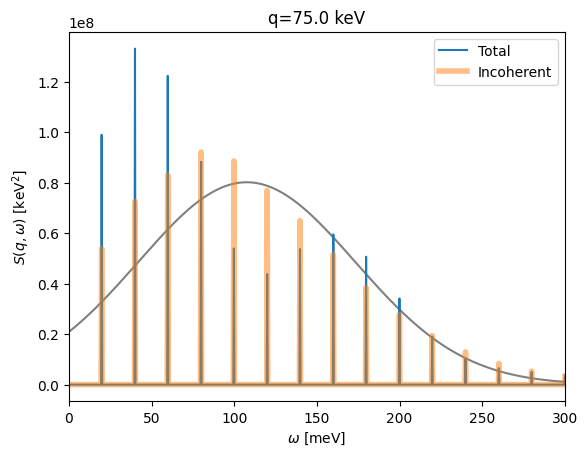

In [18]:
ind = 300
ia = get_impulse_approx(qlist[ind],omegalist,omega_avg=40e-6)
plt.plot(omegalist*1e6,ia*14,color="gray")
plt.plot(omegalist*1e6,sfactortot[ind],alpha=1,label="Total")
plt.plot(omegalist*1e6,sfactordiag[ind],alpha=0.5, lw=4,label="Incoherent")
plt.xlabel("$\omega$ [meV]")
plt.ylabel("$S(q,\omega)$ [keV$^2$]")
plt.xlim(0,300)
plt.legend()
plt.title(f"q={qlist[ind]:.1f} keV")

# plt.plot(qlist,s_diag_nobin[:,0]+s_diag_nobin[:,1]+s_offdiag_nobin[:,0]+s_offdiag_nobin[:,1])

In [19]:
nSiteData = np.load("nSite2DPlottingData.npz")
s_factor_nSite = nSiteData["s_tot"]
s_factor_nSite_incoh = nSiteData["s_diag"]
q_list_nSite = nSiteData["qlist"]
omega_list_nSite = nSiteData["omegalist"]*1e6

In [20]:
from matplotlib.colors import SymLogNorm

In [21]:
qplt, omgplt= np.meshgrid(q_list_nSite,omega_list_nSite)
omgplt.shape

(700, 600)

In [22]:
x = np.linspace(0.01,200,500)
y = x**2/2/26161e3
qbz = np.pi/(2*np.pi/2.28)
qia = 2*np.sqrt(2*40e-6*26161e3)
x_log = np.logspace(-2, 2.3,500)
y_dm = x_log*1e-3 - x_log**2/(80e3)

In [45]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix', 
    'font.size': 17              
})

Text(0.5, 0, '$q$ [keV]')

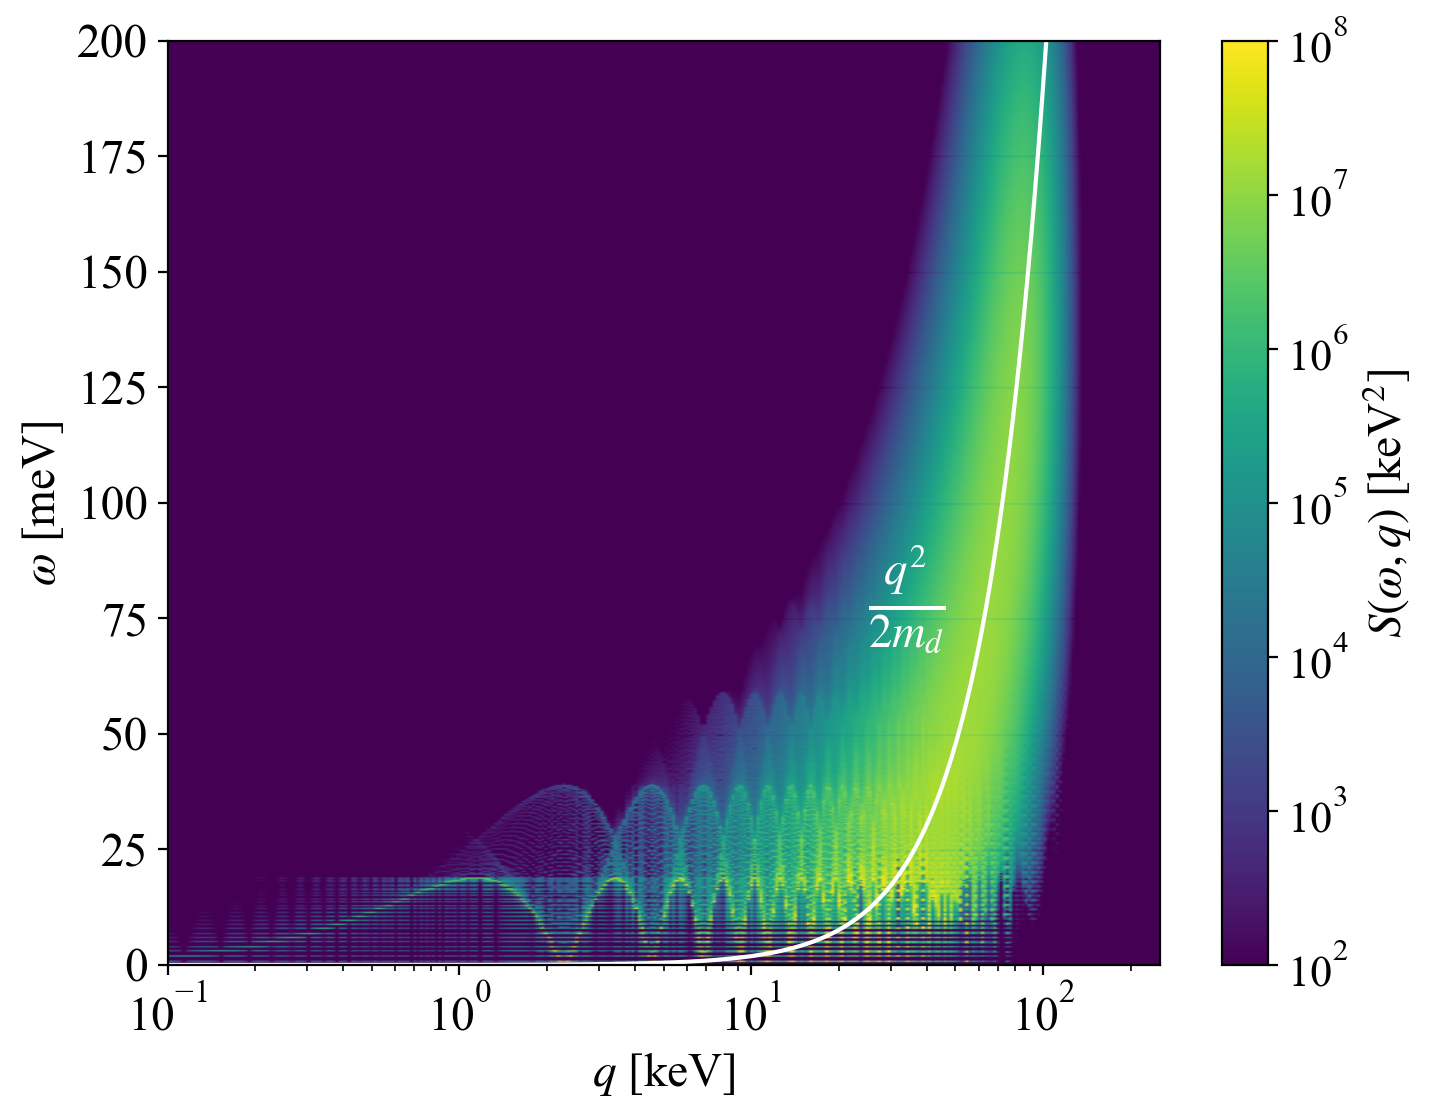

In [46]:
plt.figure(figsize=(8, 6),dpi=200)
pcm = plt.pcolormesh(qplt, omgplt, s_factor_nSite.T,shading='gouraud',norm=SymLogNorm(linthresh=0.1, vmin=0, vmax=1e8))
cbar = plt.colorbar(pcm, )
cbar.set_label("$S(\omega,q)$ [keV$^2$]")
cbar.ax.tick_params(labelsize=16)
plt.plot(x,y*1e6, color='white', label="q^2/2m")
# plt.plot(x_log,y_dm*1e6, color='white', linestyle=":")
# plt.axvline(qbz,color="gray",linestyle="--",)
# plt.axvline(qia,color="gray",linestyle="--",)
# plt.text(1.4,120,r"$q_{BZ}$",color="lightgray")
# plt.text(qia,120,r"$2\sqrt{2m_d\bar{\omega}}$",color="lightgray")
plt.xscale('log')
plt.xlim(1e-1,250)
plt.ylim(0,200)
plt.clim(1e2,1e8)
plt.text(25,75,r"$\frac{q^2}{2m_d}$",color="white",fontsize = 24)
plt.ylabel("$\omega$ [meV]")
plt.xlabel("$q$ [keV]")
 # plt.legend()
# plt.yscale('log')

Text(0.5, 1.0, 'Incoherent approximation')

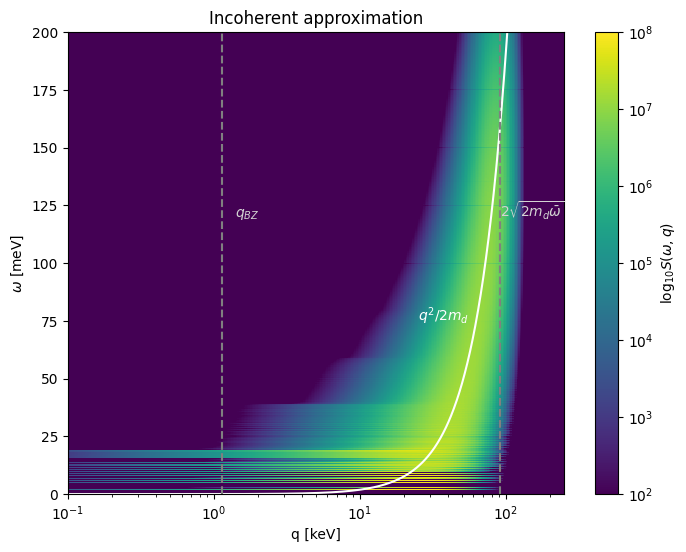

In [24]:
plt.figure(figsize=(8, 6))
pcm = plt.pcolormesh(qplt, omgplt, s_factor_nSite_incoh.T,shading='nearest',norm=SymLogNorm(linthresh=0.1, vmin=0, vmax=1e8))
cbar = plt.colorbar(pcm, )
cbar.set_label("log$_{10}S(\omega,q)$")
plt.xscale('log')
plt.clim(1e2,1e8)
plt.xlim(1e-1,250)
plt.plot(x,y*1e6, color='white', label="q^2/2m")
plt.text(25,75,"$q^2/2m_d$",color="white")
plt.axvline(qbz,color="gray",linestyle="--",)
plt.axvline(qia,color="gray",linestyle="--",)
plt.text(1.4,120,r"$q_{BZ}$",color="lightgray")
plt.text(qia,120,r"$2\sqrt{2m_d\bar{\omega}}$",color="lightgray")
plt.ylabel("$\omega$ [meV]")
plt.ylim(0,200)
plt.xlabel("q [keV]")
plt.title("Incoherent approximation")
# plt.yscale('log')

In [25]:
def get_impulse_approx(q, omega_list, omega_avg=13.13e-6, ):
    mass=26161e3 # sillicon, keV
    latticeConst= 2*np.pi/2.28 # si, keV^-3
    deltasq = q**2 * omega_avg/(2*mass)
    return 28**2 / ((latticeConst**3)/4) * np.sqrt(2*np.pi/deltasq) * np.exp(- (omega_list-(q**2/(2*mass)))**2 / (2*deltasq)) # uses averaged omega (not inverse of averaged inverse)

In [26]:
qplt.shape

(700, 600)

In [27]:
s_factor_IA = get_impulse_approx(q_list_nSite[:,np.newaxis], omega_list_nSite*1e-6, omega_avg=13.13e-6)
s_factor_IA.shape

(600, 700)

Text(0.5, 1.0, 'Impulse Approximation')

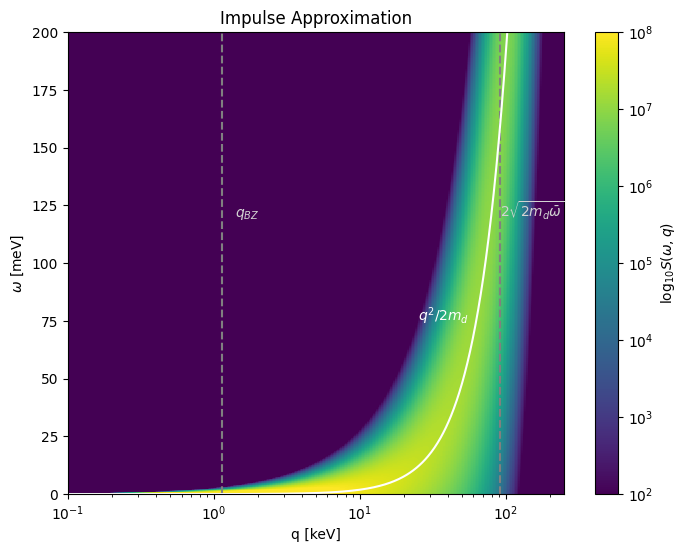

In [28]:
plt.figure(figsize=(8, 6))
pcm = plt.pcolormesh(qplt, omgplt, s_factor_IA.T,shading='nearest',norm=SymLogNorm(linthresh=0.1, vmin=0, vmax=1e8))
cbar = plt.colorbar(pcm, )
cbar.set_label("log$_{10}S(\omega,q)$")
plt.xscale('log')
plt.xlim(1e-1,250)
plt.axvline(qbz,color="gray",linestyle="--",)
plt.axvline(qia,color="gray",linestyle="--",)
plt.text(1.4,120,r"$q_{BZ}$",color="lightgray")
plt.text(qia,120,r"$2\sqrt{2m_d\bar{\omega}}$",color="lightgray")
plt.clim(1e2,1e8)
plt.plot(x,y*1e6, color='white', label="q^2/2m")
plt.text(25,75,"$q^2/2m_d$",color="white")
plt.ylabel("$\omega$ [meV]")
plt.ylim(0,200)
plt.xlabel("q [keV]")
plt.title("Impulse Approximation")

In [29]:
nSiteData = np.load("nSite2DPlottingData_zoomin.npz")
s_factor_zoom = nSiteData["s_tot"]
s_factor_zoom_incoh = nSiteData["s_diag"]
q_list_zoom = nSiteData["qlist"]
omega_list_zoom = nSiteData["omegalist"]*1e6

In [30]:
x_zoom = np.linspace(0.0,5,400)
y_zoom = np.abs(2*10*np.sin(x_zoom*2*np.pi/2.28/2))

Text(0.5, 1.0, 'Coherent corrections')

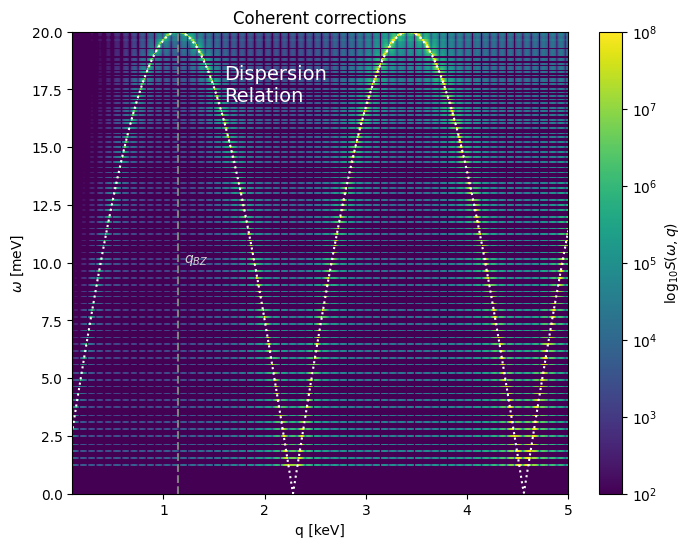

In [31]:
qplt_zoom, omgplt_zoom = np.meshgrid(q_list_zoom,omega_list_zoom)

plt.figure(figsize=(8, 6),dpi=100)
pcm = plt.pcolormesh(qplt_zoom, omgplt_zoom, s_factor_zoom.T,shading='nearest',norm=SymLogNorm(linthresh=0.1, vmin=0, vmax=1e8))
cbar = plt.colorbar(pcm, )
plt.clim(1e2,1e8)
cbar.set_label("log$_{10}S(\omega,q)$")
# plt.xscale('log')
plt.xlim(1e-1,5)
plt.ylim(0,20.0)
plt.axvline(qbz,color="gray",linestyle="--",)
plt.text(1.2,10,r"$q_{BZ}$",color="lightgray")
plt.plot(x_zoom,y_zoom, color="white",linestyle=":")
plt.text(1.6,17,"Dispersion\nRelation",color="white",fontsize=14)
plt.ylabel("$\omega$ [meV]")
plt.xlabel("q [keV]")
plt.title("Coherent corrections")


Text(0.5, 1.0, 'Incoherent approximation')

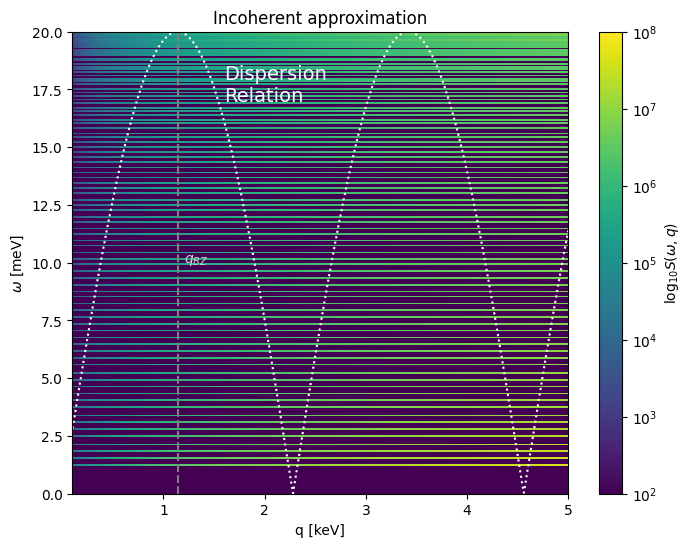

In [32]:
qplt_zoom, omgplt_zoom = np.meshgrid(q_list_zoom,omega_list_zoom)

plt.figure(figsize=(8, 6))
pcm = plt.pcolormesh(qplt_zoom, omgplt_zoom, s_factor_zoom_incoh.T,shading='nearest',norm=SymLogNorm(linthresh=0.1, vmin=0, vmax=1e8))
cbar = plt.colorbar(pcm, )
cbar.set_label("log$_{10}S(\omega,q)$")
# plt.xscale('log')
plt.xlim(1e-1,5)
plt.clim(1e2,1e8)
plt.ylim(0,20.0)
plt.axvline(qbz,color="gray",linestyle="--",)
plt.text(1.2,10,r"$q_{BZ}$",color="lightgray")
plt.plot(x_zoom,y_zoom, color="white",linestyle=":")
plt.text(1.6,17,"Dispersion\nRelation",color="white",fontsize=14)
plt.ylabel("$\omega$ [meV]")
plt.xlabel("q [keV]")
plt.title("Incoherent approximation")